# K-Nearest Neighbors | Iris Flower Classification

**Dataset:** Iris (built into sklearn -- no download needed)
**Problem:** Classify iris flowers into 3 species -- Setosa, Versicolor, Virginica -- based on 4 measurements.

Every model you have studied so far has a training phase where it learns parameters -- weights, coefficients, split thresholds, support vectors. KNN has no training phase at all. It simply stores the entire training dataset. At prediction time, it finds the K most similar training points to the new point and takes a majority vote.

This makes KNN the simplest possible algorithm conceptually, but it raises important questions about what "similar" means, how to measure distance, and what happens when features are on different scales.

**Why Iris for KNN:**
Iris has only 4 features, which means you can actually visualize the decision boundaries in 2D. With 3 perfectly balanced classes and clear geometric separation between species, it is the ideal dataset for understanding how KNN partitions space.

**What this notebook covers:**
1. The algorithm -- how KNN actually works, step by step
2. Distance metrics -- Euclidean, Manhattan, Minkowski
3. Why feature scaling is mandatory (same lesson as SVM, different reason)
4. Finding the best K -- the bias-variance tradeoff in KNN terms
5. Decision boundary visualization -- seeing what KNN actually does to space
6. Multiclass metrics -- confusion matrix, per-class precision and recall
7. KNN for regression -- the same idea applied to continuous targets
8. Strengths, weaknesses, and when to use KNN


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, LeaveOneOut
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load Dataset

In [3]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='species')

class_names = list(data.target_names)

print(f"Shape: {X.shape}")
print(f"Classes: {dict(enumerate(class_names))}")
print(f"Samples per class: perfectly balanced -- 50 each")
print()
print("Features:")
for col in X.columns:
    print(f"  {col:<25} min={X[col].min():.1f}  max={X[col].max():.1f}  mean={X[col].mean():.2f}")
print()
print("No missing values:", X.isnull().sum().sum() == 0)

Shape: (150, 4)
Classes: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
Samples per class: perfectly balanced -- 50 each

Features:
  sepal length (cm)         min=4.3  max=7.9  mean=5.84
  sepal width (cm)          min=2.0  max=4.4  mean=3.06
  petal length (cm)         min=1.0  max=6.9  mean=3.76
  petal width (cm)          min=0.1  max=2.5  mean=1.20

No missing values: True


## 2. EDA

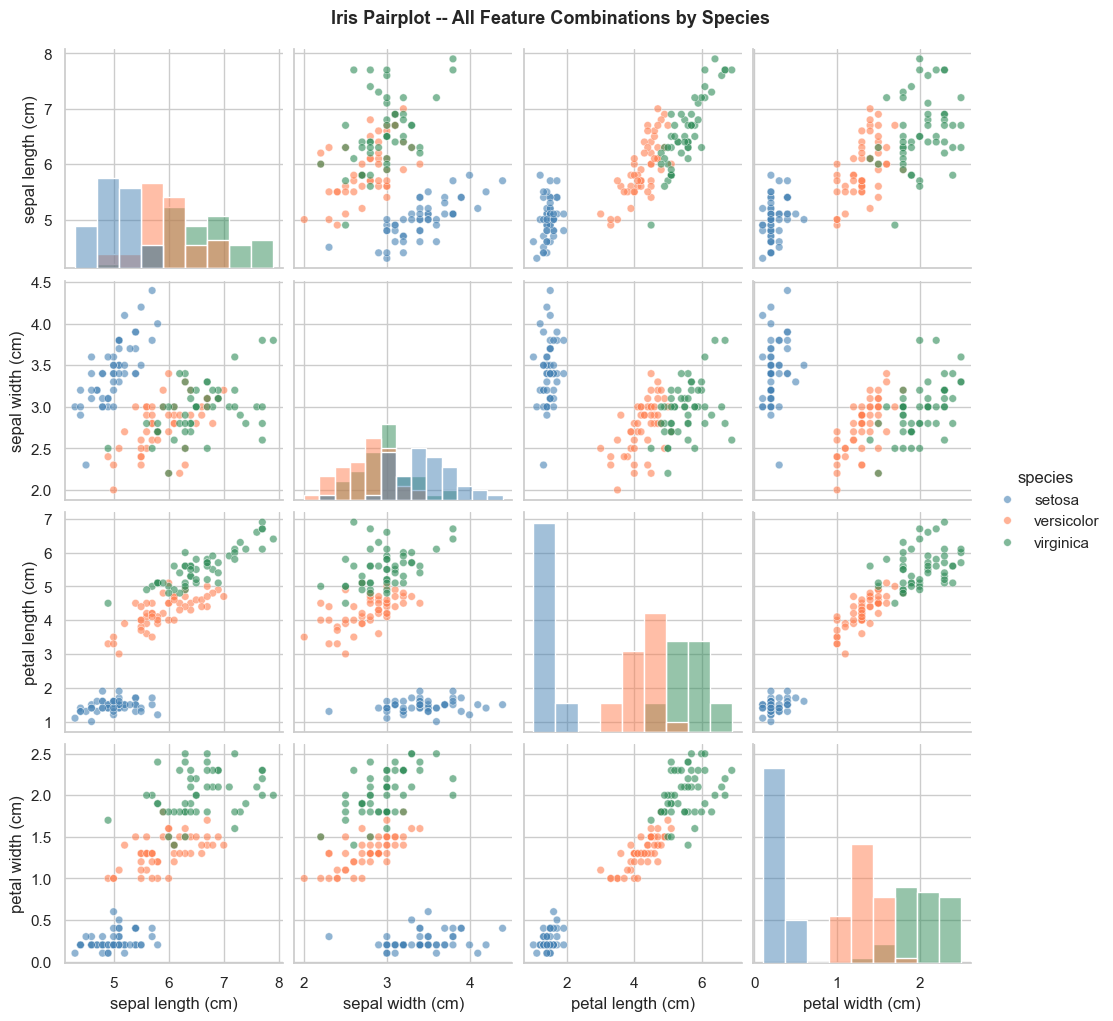

Key observations:
  Setosa is clearly separated from the other two species on petal features
  Versicolor and Virginica overlap -- harder to separate
  Petal length and petal width are the most discriminative features


In [4]:
# Pairplot -- see all feature combinations colored by species
df_plot = X.copy()
df_plot['species'] = y.map(dict(enumerate(class_names)))

g = sns.pairplot(df_plot, hue='species', diag_kind='hist',
                 palette={'setosa': 'steelblue',
                          'versicolor': 'coral',
                          'virginica': 'seagreen'},
                 plot_kws={'alpha': 0.6, 's': 30})
g.figure.suptitle('Iris Pairplot -- All Feature Combinations by Species',
                   y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("Key observations:")
print("  Setosa is clearly separated from the other two species on petal features")
print("  Versicolor and Virginica overlap -- harder to separate")
print("  Petal length and petal width are the most discriminative features")

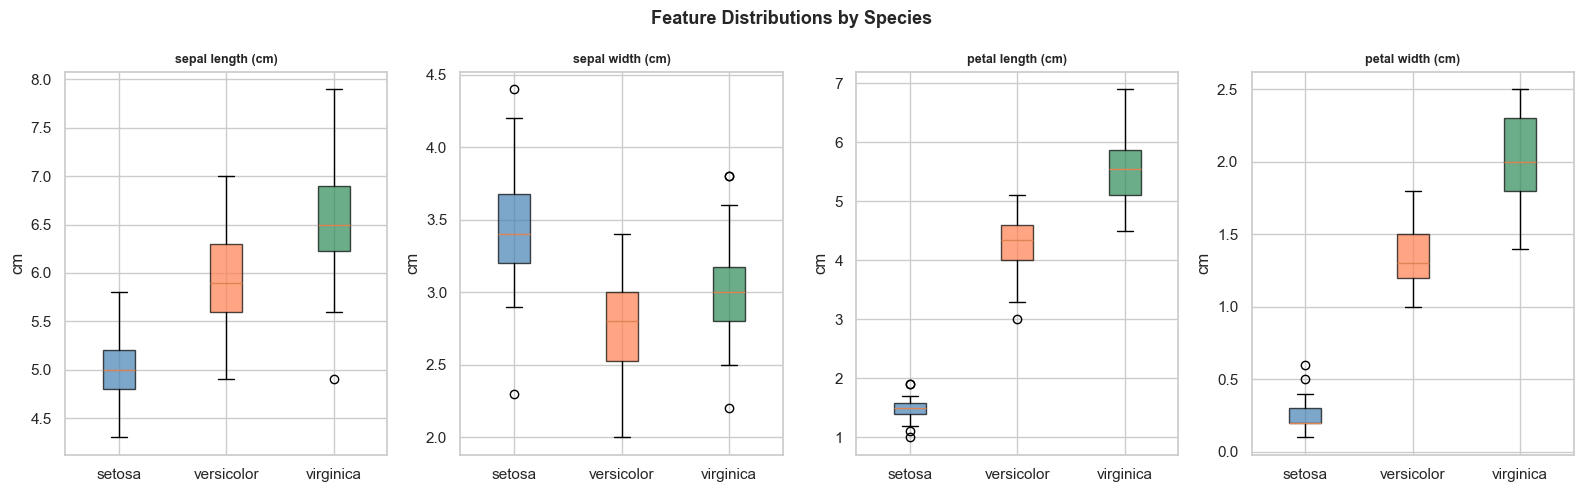

In [5]:
# Boxplots per feature
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['steelblue', 'coral', 'seagreen']

for i, col in enumerate(X.columns):
    data_by_class = [X[col][y == c].values for c in range(3)]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                          labels=class_names)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('cm')

plt.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. How KNN Actually Works

**The algorithm -- no training, pure memory:**

At prediction time for a new point x:
1. Compute the distance from x to every training point
2. Find the K training points with the smallest distance (the K nearest neighbors)
3. Take a majority vote of their class labels
4. Return that majority class as the prediction

That is the entire algorithm. There are no learned parameters, no optimization, no gradient descent. The training data IS the model.

**Distance metrics:**

Euclidean distance (default, p=2):
```
d(x, z) = sqrt(sum((xi - zi)^2))
```

Manhattan distance (p=1):
```
d(x, z) = sum(|xi - zi|)
```

Minkowski distance (general form, parameter p):
```
d(x, z) = (sum(|xi - zi|^p))^(1/p)
```
Euclidean is p=2, Manhattan is p=1.

**The K tradeoff:**
- K=1: the model assigns every new point the label of its single nearest neighbor. Maximum flexibility, maximum overfitting.
- K=n (all points): every point gets the majority class label. Complete underfitting.
- Optimal K: somewhere between -- found by cross-validation.


In [6]:
# Demonstrate the algorithm manually on one test point
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale first
scaler_demo = StandardScaler()
X_train_sc = scaler_demo.fit_transform(X_train_demo)
X_test_sc  = scaler_demo.transform(X_test_demo)

# Pick one test point
test_point = X_test_sc[0]
true_label = y_test_demo.iloc[0]

# Compute distances to all training points manually
distances = np.sqrt(np.sum((X_train_sc - test_point)**2, axis=1))

# Find K=5 nearest
K = 5
nearest_idx = np.argsort(distances)[:K]
nearest_labels = y_train_demo.iloc[nearest_idx].values
nearest_dists  = distances[nearest_idx]

print("Manual KNN prediction for one test point:")
print(f"  True label: {class_names[true_label]}")
print()
print(f"  {K} nearest neighbors:")
for i, (idx, label, dist) in enumerate(zip(nearest_idx, nearest_labels, nearest_dists)):
    print(f"    Neighbor {i+1}: {class_names[label]:<15} distance={dist:.4f}")

from collections import Counter
vote = Counter(nearest_labels)
predicted = max(vote, key=vote.get)
print()
print(f"  Vote count: {dict((class_names[k], v) for k, v in vote.items())}")
print(f"  Prediction: {class_names[predicted]}")
print(f"  Correct:    {predicted == true_label}")

Manual KNN prediction for one test point:
  True label: setosa

  5 nearest neighbors:
    Neighbor 1: setosa          distance=0.2109
    Neighbor 2: setosa          distance=0.2310
    Neighbor 3: setosa          distance=0.3465
    Neighbor 4: setosa          distance=0.4987
    Neighbor 5: setosa          distance=0.4987

  Vote count: {'setosa': 5}
  Prediction: setosa
  Correct:    True


## 4. Why Feature Scaling is Mandatory for KNN

In [7]:
# KNN uses distances -- features on larger scales dominate distance calculations
# This is the same lesson as SVM but the reason is even more direct

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# With scaling
knn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
knn_scaled.fit(X_train, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test))

print("Effect of feature scaling on KNN:")
print(f"  Without StandardScaler: {acc_unscaled:.4f}")
print(f"  With StandardScaler:    {acc_scaled:.4f}")
print()

print("Feature ranges before scaling:")
for col in X.columns:
    print(f"  {col:<25} range = {X[col].max() - X[col].min():.2f} cm")

print()
print("The feature with the largest range dominates distance calculations.")
print("StandardScaler makes every feature contribute equally to distances.")
print()
print("Rule: KNN always requires feature scaling. No exceptions.")

Effect of feature scaling on KNN:
  Without StandardScaler: 1.0000
  With StandardScaler:    0.9333

Feature ranges before scaling:
  sepal length (cm)         range = 3.60 cm
  sepal width (cm)          range = 2.40 cm
  petal length (cm)         range = 5.90 cm
  petal width (cm)          range = 2.40 cm

The feature with the largest range dominates distance calculations.
StandardScaler makes every feature contribute equally to distances.

Rule: KNN always requires feature scaling. No exceptions.


## 5. Finding the Best K

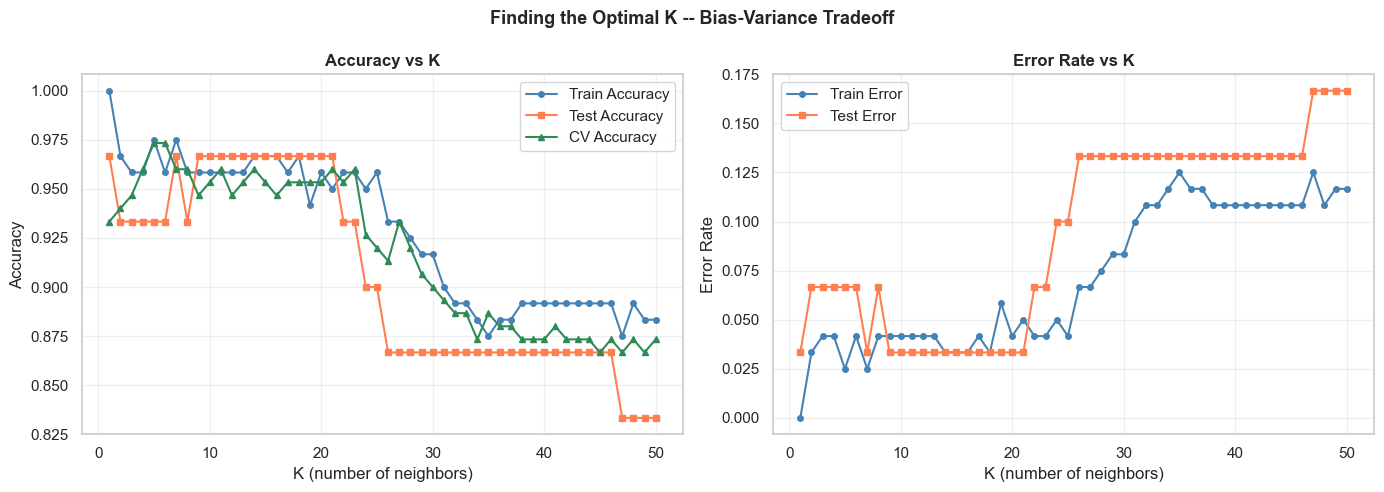

Best K by CV accuracy:   5   (CV acc=0.9733)
Best K by test accuracy: 1  (test acc=0.9667)

Always use CV accuracy to select K -- not test accuracy.
Using test accuracy to select K is a form of data leakage.


In [8]:
# K is the most important hyperparameter in KNN
# Too small: overfitting. Too large: underfitting.

k_values = range(1, 51)
train_accs, test_accs, cv_accs = [], [], []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    train_accs.append(pipe.score(X_train, y_train))
    test_accs.append(pipe.score(X_test, y_test))
    cv_score = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy').mean()
    cv_accs.append(cv_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs K
axes[0].plot(k_values, train_accs, 'o-', color='steelblue',
             markersize=4, label='Train Accuracy')
axes[0].plot(k_values, test_accs,  's-', color='coral',
             markersize=4, label='Test Accuracy')
axes[0].plot(k_values, cv_accs,    '^-', color='seagreen',
             markersize=4, label='CV Accuracy')
axes[0].set_xlabel('K (number of neighbors)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs K', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error rate vs K (sometimes clearer)
axes[1].plot(k_values, [1-a for a in train_accs], 'o-', color='steelblue',
             markersize=4, label='Train Error')
axes[1].plot(k_values, [1-a for a in test_accs],  's-', color='coral',
             markersize=4, label='Test Error')
axes[1].set_xlabel('K (number of neighbors)')
axes[1].set_ylabel('Error Rate')
axes[1].set_title('Error Rate vs K', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding the Optimal K -- Bias-Variance Tradeoff',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_cv  = k_values[np.argmax(cv_accs)]
best_k_test = k_values[np.argmax(test_accs)]
print(f"Best K by CV accuracy:   {best_k_cv}   (CV acc={max(cv_accs):.4f})")
print(f"Best K by test accuracy: {best_k_test}  (test acc={max(test_accs):.4f})")
print()
print("Always use CV accuracy to select K -- not test accuracy.")
print("Using test accuracy to select K is a form of data leakage.")

## 6. Decision Boundary Visualization

This is what makes Iris and KNN a perfect combination. With 4 features we can pick any 2 and see exactly how KNN carves up the space.

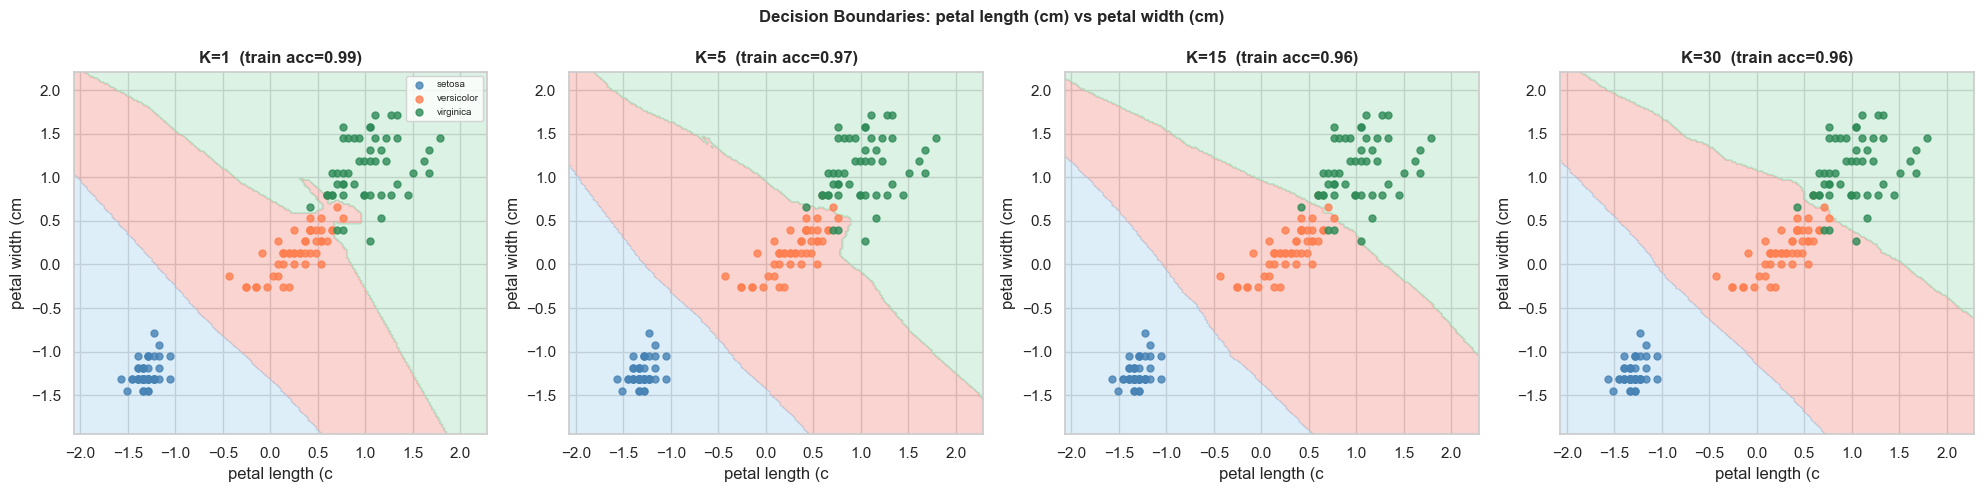

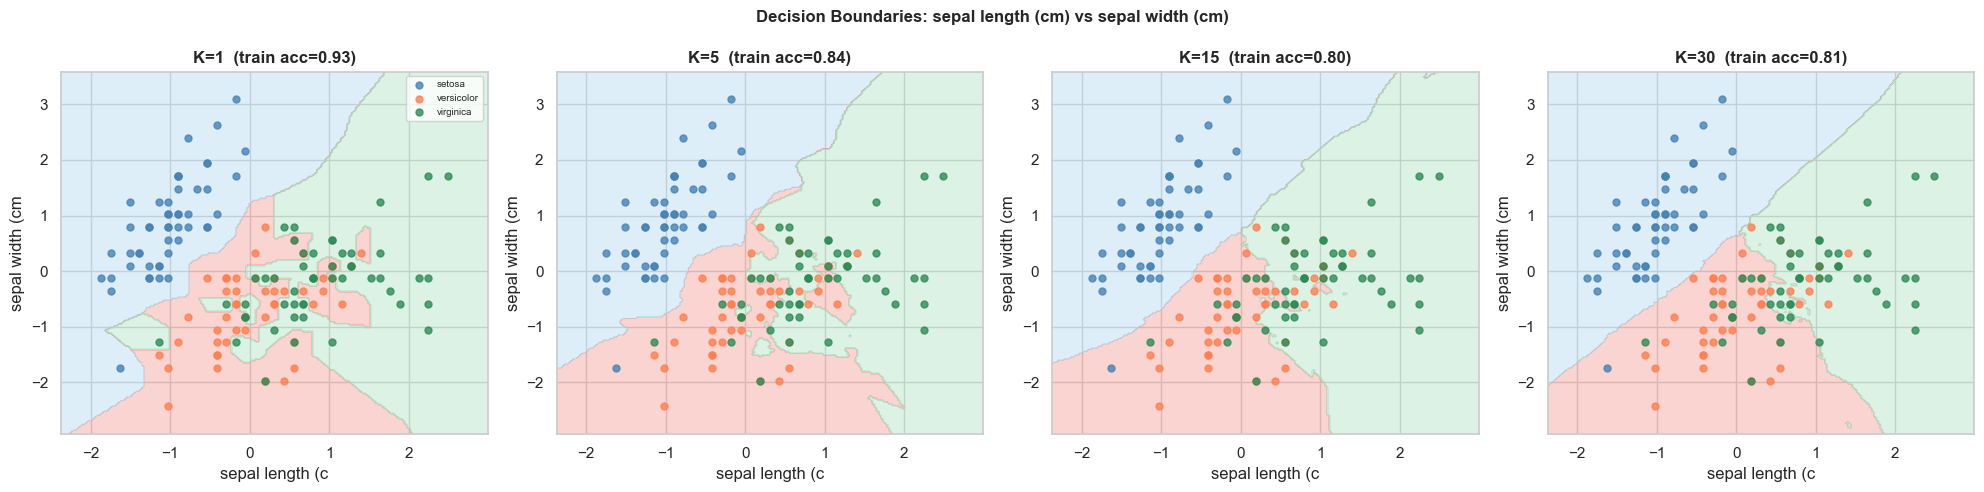

Reading the boundaries:
  K=1:  very jagged, irregular -- overfitting, memorizes every training point
  K=5:  smoother, reasonable -- good generalization
  K=15: smoother still -- may start losing fine distinctions
  K=30: very smooth -- may underfit, ignores local structure


In [9]:
# Visualize decision boundaries for different K values on 2 features
feat_pairs = [
    ('petal length (cm)', 'petal width (cm)'),    # most separable
    ('sepal length (cm)', 'sepal width (cm)'),     # less separable
]

K_values_viz = [1, 5, 15, 30]
colors_map = ListedColormap(['#AED6F1', '#F1948A', '#A9DFBF'])
colors_pts  = ['steelblue', 'coral', 'seagreen']

for feat_x, feat_y in feat_pairs:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    ix = list(X.columns).index(feat_x)
    iy = list(X.columns).index(feat_y)

    X_2d = X[[feat_x, feat_y]].values
    scaler_2d = StandardScaler()
    X_2d_sc = scaler_2d.fit_transform(X_2d)

    x_min, x_max = X_2d_sc[:,0].min()-0.5, X_2d_sc[:,0].max()+0.5
    y_min, y_max = X_2d_sc[:,1].min()-0.5, X_2d_sc[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    for ax, k in zip(axes, K_values_viz):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_2d_sc, y)

        Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=colors_map, alpha=0.4)

        for cls, color in zip(range(3), colors_pts):
            mask = y == cls
            ax.scatter(X_2d_sc[mask, 0], X_2d_sc[mask, 1],
                       color=color, s=25, alpha=0.8, label=class_names[cls])

        acc = accuracy_score(y, knn.predict(X_2d_sc))
        ax.set_title(f'K={k}  (train acc={acc:.2f})', fontweight='bold')
        ax.set_xlabel(feat_x[:15])
        ax.set_ylabel(feat_y[:15])
        if k == 1:
            ax.legend(fontsize=7)

    plt.suptitle(f'Decision Boundaries: {feat_x} vs {feat_y}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Reading the boundaries:")
print("  K=1:  very jagged, irregular -- overfitting, memorizes every training point")
print("  K=5:  smoother, reasonable -- good generalization")
print("  K=15: smoother still -- may start losing fine distinctions")
print("  K=30: very smooth -- may underfit, ignores local structure")

## 7. Distance Metric Comparison

In [10]:
# KNN supports different distance metrics via the p parameter
# p=1: Manhattan, p=2: Euclidean, p=inf: Chebyshev

distance_configs = {
    'Euclidean (p=2)':  {'metric': 'minkowski', 'p': 2},
    'Manhattan (p=1)':  {'metric': 'minkowski', 'p': 1},
    'Chebyshev':        {'metric': 'chebyshev'},
}

print(f"{'Distance Metric':<22} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 44)

for name, kwargs in distance_configs.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=best_k_cv, **kwargs))
    ])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    print(f"{name:<22} {scores.mean():>12.4f} {scores.std():>8.4f}")

print()
print("Euclidean is the standard default and works well for continuous features.")
print("Manhattan is more robust to outliers (no squaring of differences).")
print("Chebyshev uses only the largest difference across all dimensions.")

Distance Metric         CV Accuracy      Std
--------------------------------------------
Euclidean (p=2)              0.9733   0.0249
Manhattan (p=1)              0.9533   0.0452
Chebyshev                    0.9400   0.0573

Euclidean is the standard default and works well for continuous features.
Manhattan is more robust to outliers (no squaring of differences).
Chebyshev uses only the largest difference across all dimensions.


## 8. GridSearchCV -- Full Hyperparameter Search

In [11]:
param_grid = {
    'model__n_neighbors': list(range(1, 31)),
    'model__weights':     ['uniform', 'distance'],
    'model__metric':      ['euclidean', 'manhattan'],
}

pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

gs = GridSearchCV(
    pipe_gs, param_grid,
    cv=skf, scoring='accuracy',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV accuracy: {gs.best_score_:.4f}")
print()
print("weights='distance' means closer neighbors vote with more weight")
print("weights='uniform' means all K neighbors vote equally")

Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
Best CV accuracy: 0.9667

weights='distance' means closer neighbors vote with more weight
weights='uniform' means all K neighbors vote equally


In [12]:
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("=== Tuned KNN Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}  (weighted avg)")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}  (weighted avg)")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}  (weighted avg)")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

=== Tuned KNN Results ===
Accuracy:  0.9333
Precision: 0.9444  (weighted avg)
Recall:    0.9333  (weighted avg)
F1 Score:  0.9327  (weighted avg)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 9. Confusion Matrix -- Multiclass

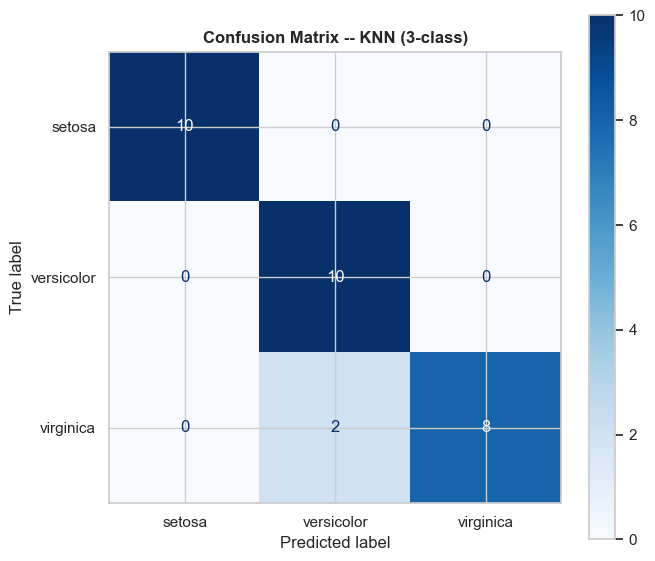

Reading the 3x3 confusion matrix:
  Rows = actual class, Columns = predicted class
  Diagonal = correct predictions
  Off-diagonal = misclassifications

Which two species does the model confuse most?
That tells you where the decision boundary is weakest.


In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix -- KNN (3-class)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Reading the 3x3 confusion matrix:")
print("  Rows = actual class, Columns = predicted class")
print("  Diagonal = correct predictions")
print("  Off-diagonal = misclassifications")
print()
print("Which two species does the model confuse most?")
print("That tells you where the decision boundary is weakest.")

## 10. Cross-Validation

In [14]:
cv_metrics = {
    'accuracy':          cross_val_score(best_model, X, y, cv=skf, scoring='accuracy'),
    'f1 (weighted)':     cross_val_score(best_model, X, y, cv=skf, scoring='f1_weighted'),
    'precision (wtd)':   cross_val_score(best_model, X, y, cv=skf, scoring='precision_weighted'),
    'recall (wtd)':      cross_val_score(best_model, X, y, cv=skf, scoring='recall_weighted'),
}

print("5-Fold Stratified Cross-Validation:")
print()
print(f"{'Metric':<18} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 70)
for metric, scores in cv_metrics.items():
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{metric:<18} {scores.mean():>8.4f} {scores.std():>8.4f}  {folds}")

5-Fold Stratified Cross-Validation:

Metric                 Mean      Std  Fold scores
----------------------------------------------------------------------
accuracy             0.9467   0.0542  1.0000  0.9667  0.8667  1.0000  0.9000
f1 (weighted)        0.9463   0.0546  1.0000  0.9666  0.8653  1.0000  0.8997
precision (wtd)      0.9494   0.0515  1.0000  0.9697  0.8750  1.0000  0.9024
recall (wtd)         0.9467   0.0542  1.0000  0.9667  0.8667  1.0000  0.9000


## 11. Leave-One-Out Cross-Validation

KNN is one of the few models where Leave-One-Out (LOO) CV is computationally feasible on small datasets. LOO uses n-1 samples for training and 1 for testing, repeated n times.

In [15]:
loo = LeaveOneOut()

# LOO on the full dataset
pipe_loo = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors=gs.best_params_['model__n_neighbors'],
        weights=gs.best_params_['model__weights'],
        metric=gs.best_params_['model__metric']
    ))
])

loo_scores = cross_val_score(pipe_loo, X, y, cv=loo, scoring='accuracy')

print(f"Leave-One-Out Cross-Validation:")
print(f"  Total folds: {len(loo_scores)} (one per sample)")
print(f"  Mean accuracy: {loo_scores.mean():.4f}")
print(f"  Std: {loo_scores.std():.4f}")
print()
print(f"  Correct predictions: {loo_scores.sum():.0f} / {len(loo_scores)}")
print(f"  Wrong predictions:   {len(loo_scores) - loo_scores.sum():.0f} / {len(loo_scores)}")
print()
print("LOO gives the least biased estimate of true performance")
print("but is expensive on large datasets (150 folds here vs 5 for standard CV).")
print("Only practical because this dataset is small -- 150 samples.")

Leave-One-Out Cross-Validation:
  Total folds: 150 (one per sample)
  Mean accuracy: 0.9467
  Std: 0.2247

  Correct predictions: 142 / 150
  Wrong predictions:   8 / 150

LOO gives the least biased estimate of true performance
but is expensive on large datasets (150 folds here vs 5 for standard CV).
Only practical because this dataset is small -- 150 samples.


## Summary

**How KNN works -- the complete picture:**
1. Store all training data (no learning happens)
2. For a new point, compute distance to every training point
3. Find the K smallest distances
4. Return majority vote (classification) or mean (regression)

**Strengths:**
- Trivial to understand and implement
- No assumptions about data distribution -- fully non-parametric
- Naturally handles multiclass problems (just vote)
- Adapts automatically to local structure in the data
- Adding new training data is instant -- just append it

**Weaknesses:**
- Prediction is slow -- O(n) per prediction where n is training size
- Memory intensive -- must store the entire training set
- Degrades badly in high-dimensional spaces (curse of dimensionality)
- Feature scaling is mandatory -- unscaled features produce meaningless distances
- No model interpretability -- cannot explain why a prediction was made

**The curse of dimensionality:**
As the number of features grows, the concept of "nearest neighbor" becomes increasingly meaningless. In high dimensions, all points become roughly equidistant from each other. KNN works best with fewer than ~20 features. Beyond that, distance metrics lose their discriminative power.

**When to use KNN:**
- Small dataset (under ~10,000 samples)
- Low to moderate number of features (under ~20)
- Non-linear decision boundaries
- You need a quick, interpretable baseline before trying complex models
- Recommendation systems (finding similar items or users)


